In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


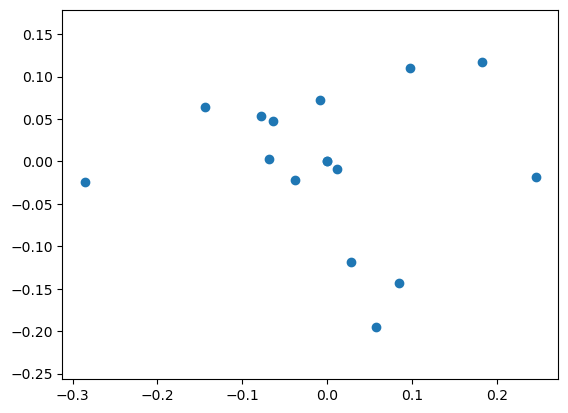

In [21]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=16,  # 轨迹的控制点数量
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.1
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.1

plt.scatter(xs, ys)
plt.axis('equal')
pass

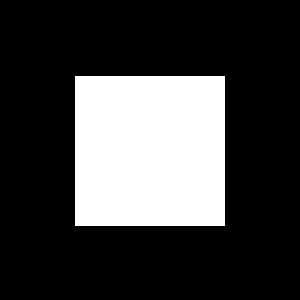

In [ ]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

normal_0 = ti.Vector([1., 0.])
normal_1 = ti.Vector([0., 1.])
normal_2 = ti.Vector([-1., 0.])
normal_3 = ti.Vector([0., -1.])
edge_distance = 0.5
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    v = ti.Vector([x2, y2])
    return ti.math.dot(v, normal_0) < edge_distance and ti.math.dot(v, normal_1) < edge_distance and ti.math.dot(v, normal_2) < edge_distance and ti.math.dot(v, normal_3) < edge_distance  # 等边正方形内是墙

image = test_forbidden_function(
    is_forbidden,
    -1, 1, -1, 1, [300, 300],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [34]:
xs, ys, rotations = np.load('../trajectory/能让等边正方形旋转一周的房间_2/sofa_380.npy')

(-0.18741946126955003,
 0.18805163284698265,
 -0.18818496208184027,
 0.1876954748816364)

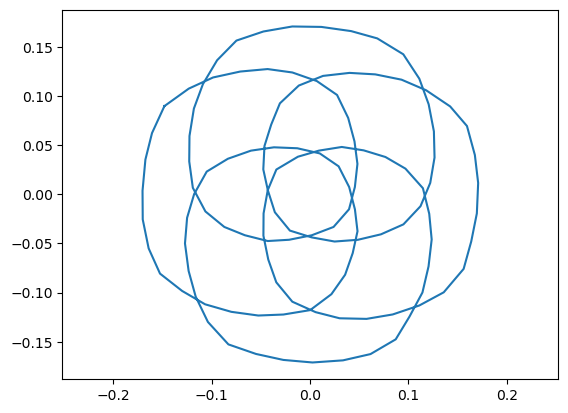

In [40]:
plt.plot(xs, ys)
plt.axis('equal')

Initial survivors: 2.5648956298828125
iter 500 / 10000, maximal_area=2.5650062561035156
iter 1000 / 10000, maximal_area=2.5650367736816406
iter 1500 / 10000, maximal_area=2.5650787353515625
iter 2000 / 10000, maximal_area=2.565155029296875
iter 2500 / 10000, maximal_area=2.565174102783203
iter 3000 / 10000, maximal_area=2.565185546875
iter 3500 / 10000, maximal_area=2.565265655517578
iter 4000 / 10000, maximal_area=2.5653228759765625
iter 4500 / 10000, maximal_area=2.565338134765625
iter 5000 / 10000, maximal_area=2.5653724670410156
iter 5500 / 10000, maximal_area=2.565410614013672
iter 6000 / 10000, maximal_area=2.5654449462890625
iter 6500 / 10000, maximal_area=2.5654640197753906
iter 7000 / 10000, maximal_area=2.565509796142578
iter 7500 / 10000, maximal_area=2.565521240234375
iter 8000 / 10000, maximal_area=2.565540313720703
iter 8500 / 10000, maximal_area=2.5655555725097656
iter 9000 / 10000, maximal_area=2.565570831298828
iter 9500 / 10000, maximal_area=2.5656051635742188
iter 10

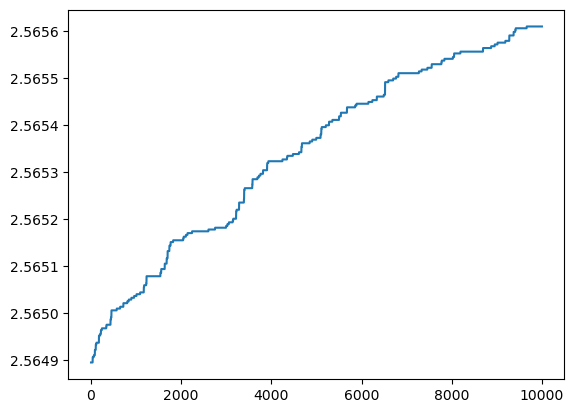

In [41]:
sofa_w, sofa_h = 2, 2   # 求解域的尺寸

best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    # xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    # ys,
    # rotations,
    initial_xs=zoom(xs, zoom=2, order=1),  # 保持轨迹分辨率时注释掉这三行
    initial_ys=zoom(ys, zoom=2, order=1),
    initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.002,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率
    iterations = 10000,  # 200000
    trajectory_upsampling=41,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=50,
    save_image_path='../images/能让等边正方形旋转一周的房间_2/sofa_',
    save_image_start_id=580,  # 文件起始标号
    save_trajectory_path='../trajectory/能让等边正方形旋转一周的房间_2/sofa_',
    boundary_conditions='periodic'  # 循环边界条件
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [45]:
area = sofa_w * sofa_h - best_score  # 房间面积
area

1.4343910217285156

In [43]:
area_disk = np.pi * (2 ** 0.5 / 2) ** 2  # 圆的面积
area_disk

1.570796326794897

In [46]:
area / area_disk

0.9131616857389098